# Modelo de Churn

Treinamento de classificadores (Random Forest, XGBoost, LightGBM) com otimização via Optuna
orientada a **F1** e **acurácia**, ajuste de threshold, interpretabilidade com SHAP
e exportação dos clientes em risco para segmentação.

## 1. Importações e configuração

In [14]:
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
N_TRIALS = 40
META_F1 = 0.80
META_ACURACIA = 0.80
PESO_F1 = 0.60
PESO_ACURACIA = 0.40

ROOT = Path('..')
MODELS_DIR = ROOT / 'models'
PROCESSED_DIR = ROOT / 'data/processed'
INTERM_DIR = ROOT / 'data/interm'

COLS_EXCLUIR = ['Churn', 'MonthlyCharges_orig', 'TotalCharges_orig', 'tenure_orig']
COLS_NORMALIZAR = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'charges_por_mes', 'charges_desvio_contrato', 'qtd_servicos',
    'qtd_servicos_protecao', 'score_risco_estendido',
    'tenure_x_contrato_mensal', 'charges_x_contrato_mensal',
]
COLS_REDUNDANTES = [
    'is_contrato_mensal', 'is_fibra_optica', 'is_boleto_eletronico', 'is_senior',
    'is_sem_suporte', 'is_sem_seguranca_online', 'score_risco_base',
]
COLS_OHE = ['InternetService', 'Contract', 'PaymentMethod', 'tenure_grupo']
COLS_BINARIAS = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
]
SERVICOS_ADICIONAIS = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]

## 2. Carregamento dos dados

Conjuntos preparados no Notebook 03, com split estratificado já aplicado.

In [15]:
treino = pd.read_parquet(PROCESSED_DIR / 'treino_modelagem.parquet')
teste = pd.read_parquet(PROCESSED_DIR / 'teste_modelagem.parquet')
feature_cols = joblib.load(MODELS_DIR / 'feature_cols.pkl')
scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
encoders_binarios = joblib.load(MODELS_DIR / 'encoders_binarios.pkl')

feature_cols = [c for c in feature_cols if c not in COLS_REDUNDANTES]
X_treino = treino[feature_cols]
y_treino = treino['Churn']
X_teste = teste[feature_cols]
y_teste = teste['Churn']

ratio_desbalanceamento = (y_treino == 0).sum() / (y_treino == 1).sum()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Treino: {X_treino.shape[0]:,} amostras | Teste: {X_teste.shape[0]:,} amostras')
print(f'Features: {len(feature_cols)} | Razão classe 0/1: {ratio_desbalanceamento:.2f}')
print(f"Churn treino: {(y_treino == 1).mean() * 100:.1f}% | Churn teste: {(y_teste == 1).mean() * 100:.1f}%")

Treino: 5,634 amostras | Teste: 1,409 amostras
Features: 47 | Razão classe 0/1: 2.77
Churn treino: 26.5% | Churn teste: 26.5%


## 3. Estratégia de modelagem — F1 e acurácia

Metas: **F1 ≥ 80%** e **acurácia ≥ 80%**, com a F-medida pesando mais que a acurácia (0,6 contra 0,4).

Pipeline:
1. Optuna maximiza **score composto** = 0,6×Fβ + 0,4×Acurácia, com **β = 0,5** (threshold ótimo por trial em CV)
2. `class_weight='balanced'` / `scale_pos_weight` no espaço de busca; SMOTE está implementado em `envolver_smote()`, porém desativado (`usar_smote = False`) — o desbalanceamento é tratado apenas por ponderação de classes
3. Seleção do melhor algoritmo pelo mesmo score em CV
4. Threshold final calibrado no treino out-of-fold

> **Por que β = 0,5:** dá mais peso à precisão que ao recall, porque cada cliente sinalizado gera uma ação comercial com custo (ligação, desconto, visita técnica). O F1 (β = 1) é reportado nas métricas finais, mas não é a função que a busca otimiza.

> **Nota:** com este dataset (~26,5% churn), o teto empírico no hold-out fica em **63,7% de F1** (threshold 0,725) e **80,6% de acurácia** (threshold 0,795).
> A meta de acurácia é atingida e o threshold calibrado coincide com o máximo de acurácia, mas a meta de F1 não é (59,6%): a fronteira da seção 7 mostra que nenhum threshold satisfaz as duas simultaneamente com as features disponíveis.

## 4. Funções auxiliares

In [16]:
def score_composto(f1, acuracia):
    return PESO_F1 * f1 + PESO_ACURACIA * acuracia


def calcular_metricas(y_true, y_pred, probas):
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return {
        'auc_roc': roc_auc_score(y_true, probas),
        'average_precision': average_precision_score(y_true, probas),
        'accuracy': acc,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1,
        'score_composto': score_composto(f1, acc),
    }


def encontrar_melhor_threshold(y_true, probas):
    """Maximiza score composto Fbeta(0.5) + acurácia — prioriza Precision."""
    melhor = None
    for t in np.arange(0.15, 0.85, 0.005):
        pred = (probas >= t).astype(int)
        fb = fbeta_score(y_true, pred, beta=0.5, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        acc = accuracy_score(y_true, pred)
        combo = PESO_F1 * fb + PESO_ACURACIA * acc
        if melhor is None or combo > melhor['score_composto']:
            melhor = {
                'threshold': t,
                'f1': f1,
                'fbeta': fb,
                'accuracy': acc,
                'precision': precision_score(y_true, pred, zero_division=0),
                'recall': recall_score(y_true, pred, zero_division=0),
                'score_composto': combo,
            }
    return melhor


def avaliar_modelo_cv(modelo, X, y, cv_folds):
    probas = cross_val_predict(
        modelo, X, y, cv=cv_folds, method='predict_proba', n_jobs=-1
    )[:, 1]
    info_thr = encontrar_melhor_threshold(y, probas)
    y_pred = (probas >= info_thr['threshold']).astype(int)
    metricas = calcular_metricas(y, y_pred, probas)
    metricas.update(info_thr)
    return metricas, probas


def envolver_smote(modelo, usar_smote):
    if usar_smote:
        return ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('clf', modelo),
        ])
    return modelo


def objetivo_f1_acuracia(modelo, X, y, cv_folds):
    probas = cross_val_predict(
        modelo, X, y, cv=cv_folds, method='predict_proba', n_jobs=-1
    )[:, 1]
    info = encontrar_melhor_threshold(y, probas)
    return info['score_composto']


def engenharia_features(df):
    """Replica a engenharia de features do Notebook 03."""
    df = df.copy()
    df['tenure_grupo'] = pd.cut(
        df['tenure'], bins=[0, 12, 24, 48, 72],
        labels=['0-12m', '13-24m', '25-48m', '49-72m'], include_lowest=True,
    )
    df['is_novo_cliente'] = (df['tenure'] <= 12).astype(int)
    df['charges_por_mes'] = np.where(
        df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges']
    )
    media_por_contrato = df.groupby('Contract')['MonthlyCharges'].transform('mean')
    df['charges_desvio_contrato'] = df['MonthlyCharges'] - media_por_contrato
    df['qtd_servicos'] = df[SERVICOS_ADICIONAIS].apply(
        lambda row: (row == 'Yes').sum(), axis=1
    )
    df['sem_servicos_adicionais'] = (df['qtd_servicos'] == 0).astype(int)
    df['is_sem_suporte'] = (df['TechSupport'] == 'No').astype(int)
    df['fibra_sem_suporte'] = (
        (df['InternetService'] == 'Fiber optic') & (df['TechSupport'] == 'No')
    ).astype(int)
    df['is_sem_seguranca_online'] = (df['OnlineSecurity'] == 'No').astype(int)
    df['qtd_servicos_protecao'] = df[
        ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection']
    ].apply(lambda row: (row == 'Yes').sum(), axis=1)
    df['sem_protecao'] = (df['qtd_servicos_protecao'] == 0).astype(int)
    df['is_contrato_mensal'] = (df['Contract'] == 'Month-to-month').astype(int)
    df['is_fibra_optica'] = (df['InternetService'] == 'Fiber optic').astype(int)
    df['is_boleto_eletronico'] = (df['PaymentMethod'] == 'Electronic check').astype(int)
    df['is_senior'] = df['SeniorCitizen'].astype(int)
    df['score_risco_base'] = (
        df['is_contrato_mensal'] + df['is_fibra_optica']
        + df['is_boleto_eletronico'] + df['is_senior']
    )
    df['score_risco_estendido'] = (
        df['score_risco_base'] + df['is_sem_suporte'] + df['is_sem_seguranca_online']
    )
    df['contrato_mensal_novo'] = df['is_contrato_mensal'] * df['is_novo_cliente']
    df['contrato_mensal_fibra'] = df['is_contrato_mensal'] * df['is_fibra_optica']
    df['tenure_x_contrato_mensal'] = df['tenure'] * df['is_contrato_mensal']
    df['charges_x_contrato_mensal'] = df['MonthlyCharges'] * df['is_contrato_mensal']
    df['boleto_x_contrato_mensal'] = df['is_boleto_eletronico'] * df['is_contrato_mensal']
    df['fibra_x_sem_protecao'] = df['is_fibra_optica'] * df['sem_protecao']
    df['tenure_curto_fibra'] = (
        (df['tenure'] <= 12) & (df['InternetService'] == 'Fiber optic')
    ).astype(int)
    df['alta_cobranca_relativa'] = (df['charges_desvio_contrato'] > 0).astype(int)
    return df


def preparar_features_base(df_raw, encoders, scaler_ref, cols_features):
    """Aplica encoding e normalização na base completa para scoring."""
    meta = df_raw[['customerID', 'Churn', 'MonthlyCharges', 'TotalCharges', 'tenure',
                   'Contract', 'InternetService', 'PaymentMethod']].copy()
    meta.columns = [
        'customerID', 'Churn', 'MonthlyCharges_orig', 'TotalCharges_orig', 'tenure_orig',
        'Contract', 'InternetService', 'PaymentMethod',
    ]

    df = engenharia_features(df_raw)
    for col in COLS_BINARIAS:
        df[col] = encoders[col].transform(df[col].astype(str))
    df = pd.get_dummies(df, columns=COLS_OHE, drop_first=False)
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    for col in cols_features:
        if col not in df.columns:
            df[col] = 0

    X = df[cols_features].copy()
    cols_norm = [c for c in COLS_NORMALIZAR if c in X.columns]
    X[cols_norm] = scaler_ref.transform(X[cols_norm].astype(float))
    return X, meta

## 5. Otimização de hiperparâmetros (Optuna)

Busca bayesiana com objetivo **score composto** (0,6×F1 + 0,4×Acurácia) em validação cruzada.
Cada trial inclui threshold ótimo, `class_weight`/`scale_pos_weight` e SMOTE opcional.

In [17]:
def criar_objetivo_rf(X, y, cv_folds):
    def objetivo(trial):
        usar_smote = False
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 800),
            'max_depth': trial.suggest_int('max_depth', 6, 24),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'class_weight': 'balanced',
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
        }
        modelo = envolver_smote(RandomForestClassifier(**params), usar_smote)
        return objetivo_f1_acuracia(modelo, X, y, cv_folds)
    return objetivo


def criar_objetivo_xgb(X, y, cv_folds, scale_weight):
    def objetivo(trial):
        usar_smote = False
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'scale_pos_weight': trial.suggest_float(
                'scale_pos_weight', scale_weight * 1.5, scale_weight * 4.0
            ),
            'eval_metric': 'logloss',
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'verbosity': 0,
        }
        modelo = envolver_smote(xgb.XGBClassifier(**params), usar_smote)
        return objetivo_f1_acuracia(modelo, X, y, cv_folds)
    return objetivo


def criar_objetivo_lgbm(X, y, cv_folds, scale_weight):
    def objetivo(trial):
        usar_smote = False
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 128),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight': trial.suggest_float(
                'scale_pos_weight', scale_weight * 1.5, scale_weight * 4.0
            ),
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'verbose': -1,
        }
        modelo = envolver_smote(lgb.LGBMClassifier(**params), usar_smote)
        return objetivo_f1_acuracia(modelo, X, y, cv_folds)
    return objetivo


def otimizar_modelo(nome, objetivo):
    study = optuna.create_study(direction='maximize', study_name=nome)
    study.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=True)
    print(f'\n{nome}: melhor score composto CV = {study.best_value:.4f}')
    return study


study_rf = otimizar_modelo('RandomForest', criar_objetivo_rf(X_treino, y_treino, cv))
study_xgb = otimizar_modelo('XGBoost', criar_objetivo_xgb(X_treino, y_treino, cv, ratio_desbalanceamento))
study_lgbm = otimizar_modelo('LightGBM', criar_objetivo_lgbm(X_treino, y_treino, cv, ratio_desbalanceamento))

Best trial: 36. Best value: 0.699561: 100%|██████████| 40/40 [05:21<00:00,  8.05s/it]



RandomForest: melhor score composto CV = 0.6996


Best trial: 22. Best value: 0.703124: 100%|██████████| 40/40 [02:01<00:00,  3.03s/it]



XGBoost: melhor score composto CV = 0.7031


Best trial: 27. Best value: 0.701385: 100%|██████████| 40/40 [03:49<00:00,  5.75s/it]


LightGBM: melhor score composto CV = 0.7014


## 6. Seleção do melhor modelo e threshold

Compara os três modelos pelo **score composto** em CV e calibra o threshold no treino out-of-fold.

In [18]:
def instanciar_modelo(nome, best_params):
    params = best_params.copy()
    usar_smote = params.pop('usar_smote', False)

    if nome == 'RandomForest':
        base = RandomForestClassifier(
            **params,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    elif nome == 'XGBoost':
        base = xgb.XGBClassifier(
            **params,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    else:
        base = lgb.LGBMClassifier(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    return envolver_smote(base, usar_smote)


candidatos = {
    'RandomForest': study_rf.best_params,
    'XGBoost': study_xgb.best_params,
    'LightGBM': study_lgbm.best_params,
}

resultados_cv = []
for nome, params in candidatos.items():
    modelo = instanciar_modelo(nome, params)
    metricas, _ = avaliar_modelo_cv(modelo, X_treino, y_treino, cv)
    resultados_cv.append({'modelo': nome, **metricas})

df_comparacao = (
    pd.DataFrame(resultados_cv)
    .sort_values('score_composto', ascending=False)
    .reset_index(drop=True)
)
display(df_comparacao.round(4))

melhor_nome = df_comparacao.loc[0, 'modelo']
modelo_final = instanciar_modelo(melhor_nome, candidatos[melhor_nome])

probas_cv = cross_val_predict(
    modelo_final, X_treino, y_treino, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]
info_threshold = encontrar_melhor_threshold(y_treino, probas_cv)
melhor_threshold = info_threshold['threshold']

modelo_final.fit(X_treino, y_treino)
modelo_shap = modelo_final.named_steps['clf'] if hasattr(modelo_final, 'named_steps') else modelo_final

print(f'\nModelo selecionado: {melhor_nome}')
print(f"Threshold (max score composto): {melhor_threshold:.3f}")
print(
    f"  CV → F1={info_threshold['f1']:.3f} | "
    f"Acurácia={info_threshold['accuracy']:.3f} | "
    f"Score={info_threshold['score_composto']:.3f}"
)
print(f"  Metas → F1={META_F1:.0%} | Acurácia={META_ACURACIA:.0%}")

,modelo,auc_roc,average_precision,accuracy,precision,recall,f1,score_composto,threshold,fbeta
0,XGBoost,0.8467,0.6593,0.8055,0.6634,0.5418,0.5965,0.7031,0.795,0.6349
1,LightGBM,0.8476,0.6600,0.8046,0.6522,0.5645,0.6052,0.7014,0.795,0.6326
2,RandomForest,0.8473,0.6598,0.8035,0.6470,0.5712,0.6067,0.6996,0.685,0.6303



Modelo selecionado: XGBoost
Threshold (max score composto): 0.795
  CV → F1=0.596 | Acurácia=0.805 | Score=0.703
  Metas → F1=80% | Acurácia=80%


## 7. Avaliação no conjunto de teste

Métricas no conjunto de teste (hold-out):
  auc_roc: 0.8469
  average_precision: 0.6616
  accuracy: 0.8055
  precision: 0.6645
  recall: 0.5401
  f1: 0.5959
  score_composto: 0.6797

  Meta F1 ≥ 80%: ✗ (59.6%)
  Meta Acurácia ≥ 80%: ✓ (80.6%)

Relatório de classificação:
              precision    recall  f1-score   support

   Não Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



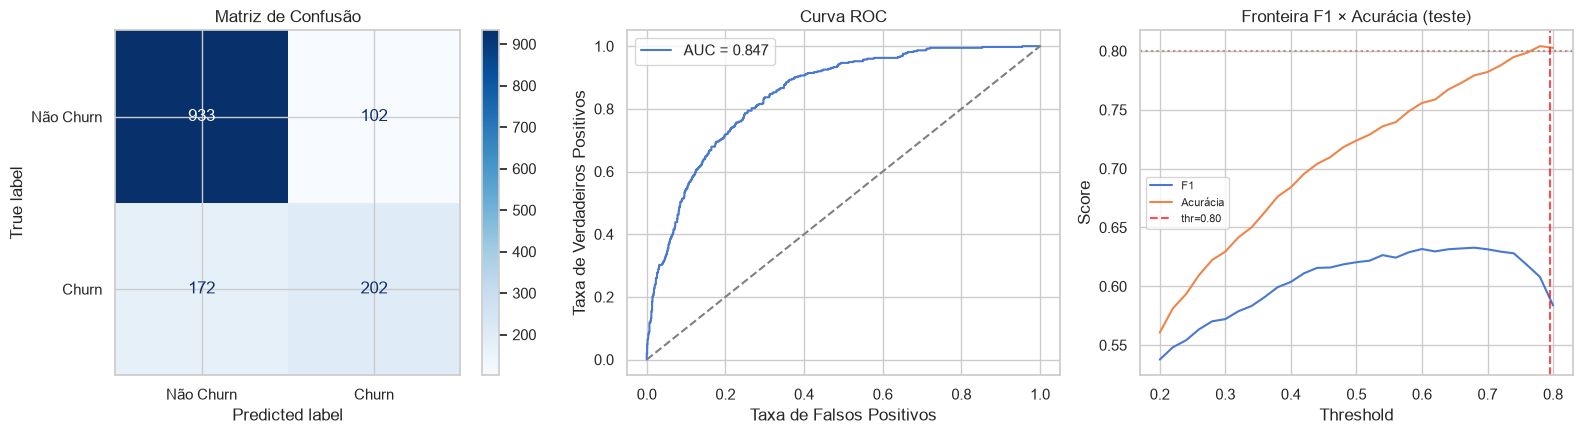


Resumo operacional (teste):
  Verdadeiros positivos: 202 | Falsos positivos: 102 | Falsos negativos: 172
  F1=59.6% | Acurácia=80.6% | Precisão=66.4% | Recall=54.0%


In [19]:
probas_teste = modelo_final.predict_proba(X_teste)[:, 1]
y_pred_teste = (probas_teste >= melhor_threshold).astype(int)
metricas_teste = calcular_metricas(y_teste, y_pred_teste, probas_teste)

print('Métricas no conjunto de teste (hold-out):')
for metrica, valor in metricas_teste.items():
    print(f'  {metrica}: {valor:.4f}')

atinge_f1 = metricas_teste['f1'] >= META_F1
atinge_acc = metricas_teste['accuracy'] >= META_ACURACIA
print(f"\n  Meta F1 ≥ {META_F1:.0%}: {'✓' if atinge_f1 else '✗'} ({metricas_teste['f1']:.1%})")
print(f"  Meta Acurácia ≥ {META_ACURACIA:.0%}: {'✓' if atinge_acc else '✗'} ({metricas_teste['accuracy']:.1%})")

print('\nRelatório de classificação:')
print(classification_report(y_teste, y_pred_teste, target_names=['Não Churn', 'Churn']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_teste, y_pred_teste, display_labels=['Não Churn', 'Churn'],
    cmap='Blues', ax=axes[0],
)
axes[0].set_title('Matriz de Confusão')

fpr, tpr, _ = roc_curve(y_teste, probas_teste)
axes[1].plot(fpr, tpr, label=f"AUC = {metricas_teste['auc_roc']:.3f}")
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()

# Fronteira F1 × Acurácia por threshold (teste)
thresholds_plot = np.arange(0.20, 0.80, 0.02)
f1s, accs = [], []
for t in thresholds_plot:
    pred = (probas_teste >= t).astype(int)
    f1s.append(f1_score(y_teste, pred, zero_division=0))
    accs.append(accuracy_score(y_teste, pred))
axes[2].plot(thresholds_plot, f1s, label='F1')
axes[2].plot(thresholds_plot, accs, label='Acurácia')
axes[2].axhline(META_F1, color='C0', linestyle=':', alpha=0.6)
axes[2].axhline(META_ACURACIA, color='C1', linestyle=':', alpha=0.6)
axes[2].axvline(melhor_threshold, color='red', linestyle='--', alpha=0.7, label=f'thr={melhor_threshold:.2f}')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Fronteira F1 × Acurácia (teste)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_teste, y_pred_teste).ravel()
print(f'\nResumo operacional (teste):')
print(f'  Verdadeiros positivos: {tp} | Falsos positivos: {fp} | Falsos negativos: {fn}')
print(f"  F1={metricas_teste['f1']:.1%} | Acurácia={metricas_teste['accuracy']:.1%} | Precisão={metricas_teste['precision']:.1%} | Recall={metricas_teste['recall']:.1%}")

## 8. Interpretabilidade com SHAP

SHAP quantifica a contribuição de cada feature para a predição individual, essencial para explicar
por que um cliente foi classificado como em risco e orientar ações de retenção.


Top 15 features por |SHAP| médio (conjunto de teste):


,feature,shap_medio_abs
0,charges_x_contrato_mensal,0.6361
1,score_risco_estendido,0.4324
2,tenure,0.3221
3,Contract_Two year,0.1802
4,charges_por_mes,0.1431
5,TotalCharges,0.1404
6,MonthlyCharges,0.1213
7,PaperlessBilling,0.1213
8,tenure_curto_fibra,0.1098
9,charges_desvio_contrato,0.0819


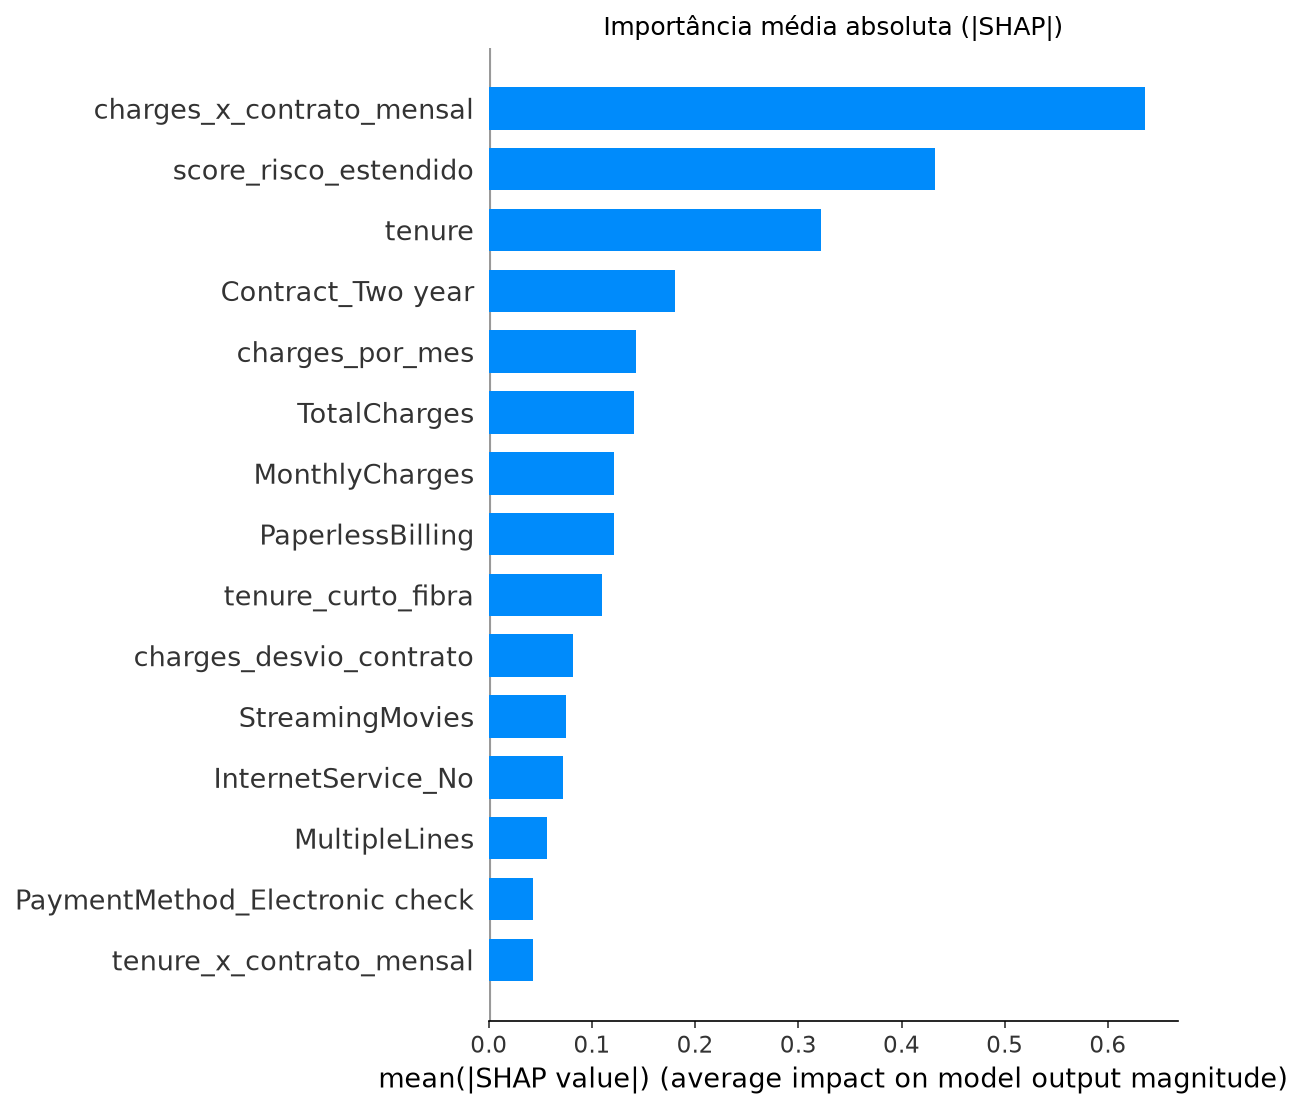

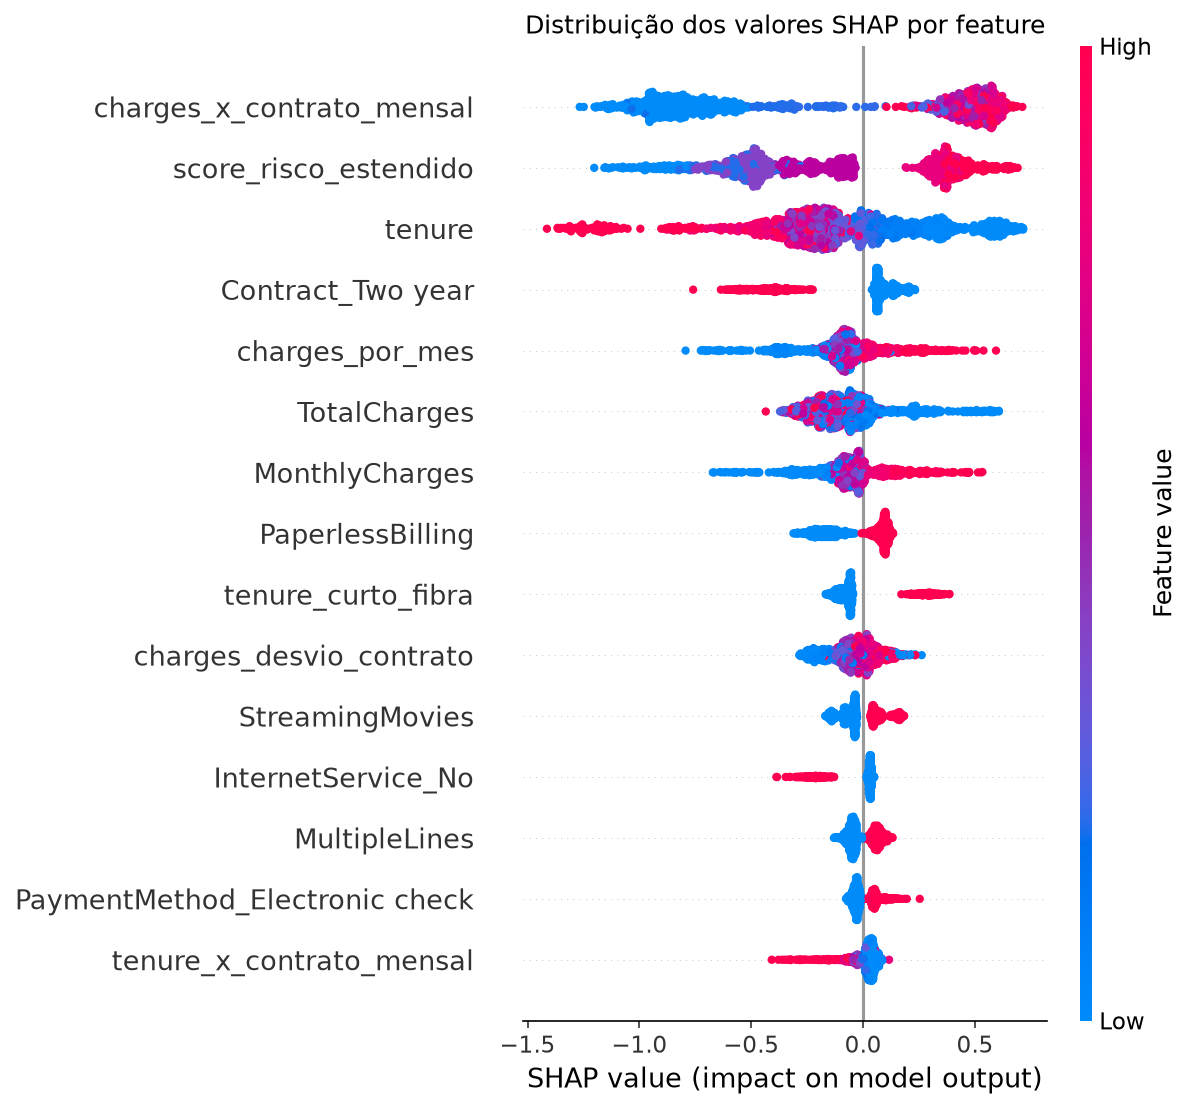

Cliente exemplo (índice 1109): prob_churn=0.968 | churn real=1 | threshold=0.795


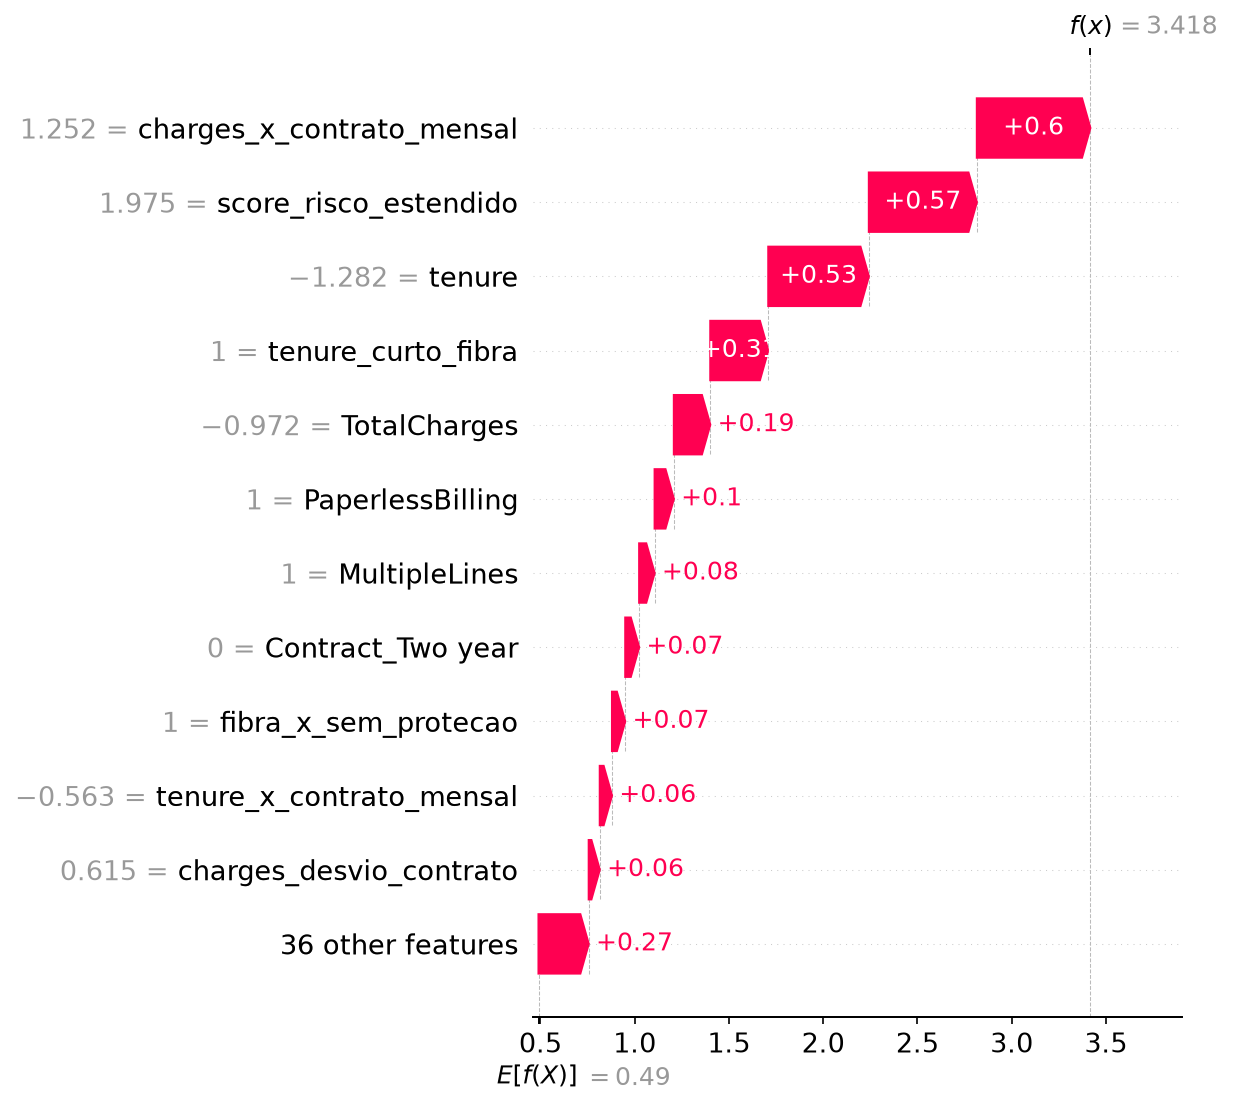

In [20]:
explainer = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(X_teste)

importancia_shap = (
    pd.DataFrame({
        'feature': feature_cols,
        'shap_medio_abs': np.abs(shap_values).mean(axis=0),
    })
    .sort_values('shap_medio_abs', ascending=False)
    .reset_index(drop=True)
)

print('Top 15 features por |SHAP| médio (conjunto de teste):')
display(importancia_shap.head(15).round(4))

shap.summary_plot(shap_values, X_teste, plot_type='bar', max_display=15, show=False)
plt.title('Importância média absoluta (|SHAP|)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_teste, max_display=15, show=False)
plt.title('Distribuição dos valores SHAP por feature')
plt.tight_layout()
plt.show()

# Explicação individual: cliente de maior probabilidade estimada no teste
idx_exemplo = int(np.argmax(probas_teste))
print(
    f'Cliente exemplo (índice {idx_exemplo}): '
    f'prob_churn={probas_teste[idx_exemplo]:.3f} | '
    f'churn real={int(y_teste.iloc[idx_exemplo])} | '
    f'threshold={melhor_threshold:.3f}'
)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx_exemplo],
        base_values=explainer.expected_value,
        data=X_teste.iloc[idx_exemplo].values,
        feature_names=list(feature_cols),
    ),
    max_display=12,
    show=False,
)
plt.tight_layout()
plt.show()


## 9. Scoring da base completa e exportação

Aplica o modelo na base consolidada inteira (7.043 clientes) e exporta os classificados como em risco
para alimentar o Notebook 05 (segmentação).

In [21]:
base = pd.read_parquet(INTERM_DIR / 'base_consolidada.parquet')
X_base, meta_base = preparar_features_base(base, encoders_binarios, scaler, feature_cols)

probas_base = modelo_final.predict_proba(X_base)[:, 1]
pred_base = (probas_base >= melhor_threshold).astype(int)

scoring = meta_base.copy()
scoring['prob_churn'] = probas_base
scoring['predicao_churn'] = pred_base
scoring['em_risco'] = pred_base.astype(bool)

# Features comportamentais para clustering (NB05)
for col in feature_cols:
    scoring[col] = X_base[col].values

clientes_em_risco = scoring[scoring['em_risco']].copy().reset_index(drop=True)

print(f'Base total: {len(scoring):,} clientes')
print(f"Em risco (threshold={melhor_threshold:.2f}): {len(clientes_em_risco):,} ({len(clientes_em_risco)/len(scoring)*100:.1f}%)")
print(f"Churn real entre flagged: {clientes_em_risco['Churn'].mean()*100:.1f}%")
print(f"Churn real na base: {scoring['Churn'].mean()*100:.1f}%")

display(clientes_em_risco.head())

Base total: 7,043 clientes
Em risco (threshold=0.80): 1,556 (22.1%)
Churn real entre flagged: 69.5%
Churn real na base: 26.5%


,customerID,Churn,MonthlyCharges_orig,TotalCharges_orig,tenure_orig,Contract,InternetService,PaymentMethod,prob_churn,predicao_churn,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_grupo_0-12m,tenure_grupo_13-24m,tenure_grupo_25-48m,tenure_grupo_49-72m
0,7590-VHVEG,0,29.85,29.85,1,Month-to-month,DSL,Electronic check,0.904681,1,...,0,0,0,0,1,0,1,0,0,0
1,9237-HQITU,1,70.70,151.65,2,Month-to-month,Fiber optic,Electronic check,0.883966,1,...,0,0,0,0,1,0,1,0,0,0
2,9305-CDSKC,1,99.65,820.50,8,Month-to-month,Fiber optic,Electronic check,0.954826,1,...,0,0,0,0,1,0,1,0,0,0
3,7892-POOKP,1,104.80,3046.05,28,Month-to-month,Fiber optic,Electronic check,0.868959,1,...,0,0,0,0,1,0,0,0,1,0
4,0280-XJGEX,1,103.70,5036.30,49,Month-to-month,Fiber optic,Bank transfer (automatic),0.810343,1,...,0,0,1,0,0,0,0,0,0,1


## 10. Exportação dos artefatos

In [22]:
artefato_modelo = {
    'modelo': modelo_final,
    'modelo_shap': modelo_shap,
    'nome_modelo': melhor_nome,
    'threshold': melhor_threshold,
    'meta_f1': META_F1,
    'meta_acuracia': META_ACURACIA,
    'peso_f1': PESO_F1,
    'feature_cols': feature_cols,
    'metricas_teste': metricas_teste,
    'metricas_cv': df_comparacao.to_dict('records'),
    'hiperparametros': candidatos[melhor_nome],
}

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(artefato_modelo, MODELS_DIR / 'modelo_churn.pkl')
clientes_em_risco.to_parquet(PROCESSED_DIR / 'clientes_em_risco.parquet', index=False)

print('Artefatos exportados:')
print(f'  {MODELS_DIR / "modelo_churn.pkl"}')
print(f'  {PROCESSED_DIR / "clientes_em_risco.parquet"}')
print(f'    → {len(clientes_em_risco):,} clientes x {clientes_em_risco.shape[1]} colunas')
print('\nModelo de Churn (Notebook 04) processado com sucesso!')

Artefatos exportados:
  ..\models\modelo_churn.pkl
  ..\data\processed\clientes_em_risco.parquet
    → 1,556 clientes x 58 colunas

Modelo de Churn (Notebook 04) processado com sucesso!
